<a href="https://colab.research.google.com/github/NATHAN-70/AI-ML/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb

In [ ]:
vacob_size=10000
(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=vacob_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_length=200
x_train=pad_sequences(x_train,maxlen=max_length)
x_test=pad_sequences(x_test,maxlen=max_length)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,SimpleRNN

In [ ]:
model=Sequential()
model.add(Embedding(input_dim=vacob_size,output_dim=100,input_length=max_length))
model.add(SimpleRNN(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
rnn=model.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.6147 - loss: 0.6467 - val_accuracy: 0.6592 - val_loss: 0.5967
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.7060 - loss: 0.6642 - val_accuracy: 0.6676 - val_loss: 0.5733
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.7976 - loss: 0.4384 - val_accuracy: 0.7744 - val_loss: 0.4693
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8739 - loss: 0.3296 - val_accuracy: 0.7724 - val_loss: 0.4942
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.9111 - loss: 0.2292 - val_accuracy: 0.8262 - val_loss: 0.4166


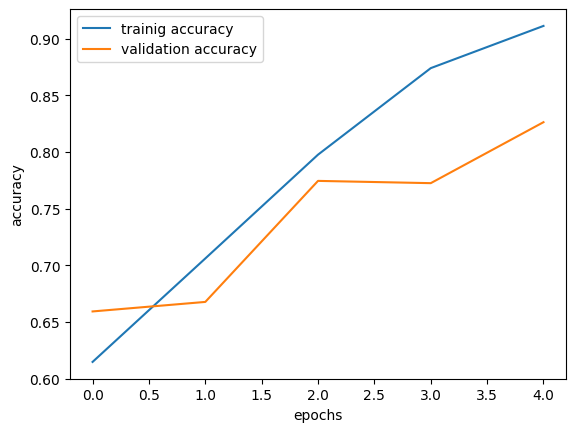

In [ ]:
import matplotlib.pyplot as plt
plt.plot(rnn.history['accuracy'],label='trainig accuracy')
plt.plot(rnn.history['val_accuracy'],label='validation accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
loss,accuracy=model.evaluate(x_test,y_test)
print('loss:',loss)
print('accuracy:',accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8227 - loss: 0.4175
loss: 0.41749465465545654
accuracy: 0.8226799964904785


In [ ]:
predictions=model.predict(x_test[:5])
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
[[0.33478975]
 [0.9755598 ]
 [0.2258105 ]
 [0.84139884]
 [0.999794  ]]


### Making predictions on the entire test set

In [ ]:
all_predictions = model.predict(x_test)
print(all_predictions[:5]) # Displaying the first 5 predictions

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step
[[0.33478972]
 [0.9755598 ]
 [0.2258105 ]
 [0.84139884]
 [0.999794  ]]


### Classifying a single example

To classify a single example, you need to ensure it has the same shape and preprocessing as your training data. Here, I'll take the first example from `x_test` and reshape it for prediction.

In [ ]:
word_index = imdb.get_word_index()
def preprocess_text(text):
    words = text.lower().split()
    # Convert words to integer IDs, handle out-of-vocabulary words
    encoded_review = [word_index.get(word, 2) + 3 for word in words] # 2 is for unknown words, 0, 1, 2 are reserved
    # Pad the sequence
    padded_review = pad_sequences([encoded_review], maxlen=max_length)
    return padded_review

custom_review_text = " movie"
preprocessed_input = preprocess_text(custom_review_text)

# Make prediction
custom_prediction = model.predict(preprocessed_input)
print(f"Custom review: '{custom_review_text}'")
print(f"Prediction: {custom_prediction[0][0]:.4f}")

# Convert prediction to a class (0 for negative, 1 for positive)
predicted_class = 1 if custom_prediction[0][0] > 0.5 else 0
sentiment = "Positive" if predicted_class == 1 else "Negative"
print(f"Predicted sentiment: {sentiment}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Custom review: 'not nice movie'
Prediction: 0.9219
Predicted sentiment: Positive


In [ ]:
# This line processes each 'word' in the 'words' list (which is the input text split into words).
#
# 1. `word_index.get(word, 2)`: It looks up the integer ID for each `word` in the `word_index` dictionary.
#    - If the `word` is found, its corresponding integer ID is returned.
#    - If the `word` is NOT found (it's an 'out-of-vocabulary' word), it returns the default value `2`.
#      (In the IMDB dataset, `2` is often reserved for 'unknown' words).
#
# 2. `+ 3`: An offset of `3` is added to the retrieved integer ID. This is a common practice with the IMDB dataset
#    because indices `0`, `1`, and `2` are reserved for special purposes:
#    - `0`: Padding
#    - `1`: Start of sequence
#    - `2`: Unknown word
#    By adding `3`, all actual word indices are shifted to start from `3` or higher,
#    preventing collisions with these reserved special tokens.